In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from python_utils.visualization_utils import perc, SetPlotRC, ApplyFont, format_results_for_jupyter_and_latex
from python_utils.visualization_utils import plot_pcl_convergence_ci, plot_pcl_convergence_w_quantiles, plot_pcl_convergence_boxplot

import warnings
warnings.filterwarnings("ignore")

In [2]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# Synthetic High Dim Results with Log Cosh Loss

In [3]:
df_NME_2000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_log_cosh_2000_2026-04-24_12-48-24.csv")
df_NME_5000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_log_cosh_5000_2026-04-24_13-11-22.csv")
df_NME_10000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_log_cosh_10000_2026-04-24_13-12-14.csv")
df_NME_15000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_log_cosh_15000_2026-04-24_13-19-44.csv")
df_NME_20000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_log_cosh_20000_2026-04-24_13-25-39.csv")

df_PKDR = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/PKDR_SyntheticHighDim_NewVersion_V1_Results_2000_5000_10000_15000_20000_2026-04-12_16-53-50.csv")
df_KPV = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/KPV_Synthetic_High_Dim_Results_2000_5000_10000_15000_20000_2026-04-24_13-11-12.csv")
df_results = pd.concat([df_NME_2000, df_NME_5000, df_NME_10000, df_NME_15000, df_NME_20000, df_PKDR, df_KPV], axis = 0)

df_NME_20000.tail()

,Algorithm,Data_Size,Seed,Causal_MSE,out_experiment_name,out_disable_first_stage,out_lr_first_stage_base,out_lr_second_stage_ax,out_lr_second_stage_w,out_second_stage_head_lr,...,treat_negative_penalty,third_lr,third_weight_decay,third_n_epochs,third_gap_penalty_weight,third_log_per_epoch,third_input_dim,third_output_dim,third_hidden_dims,third_dropout_rate
115,DRPCLNET_Version2,20000,2800,0.007042,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
116,OutcomeBridgePCLNET,20000,2900,0.004680,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
117,TreatmentBridgePCLNET,20000,2900,0.106932,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
118,DRPCLNET_Version1,20000,2900,0.005739,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
119,DRPCLNET_Version2,20000,2900,0.008113,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1


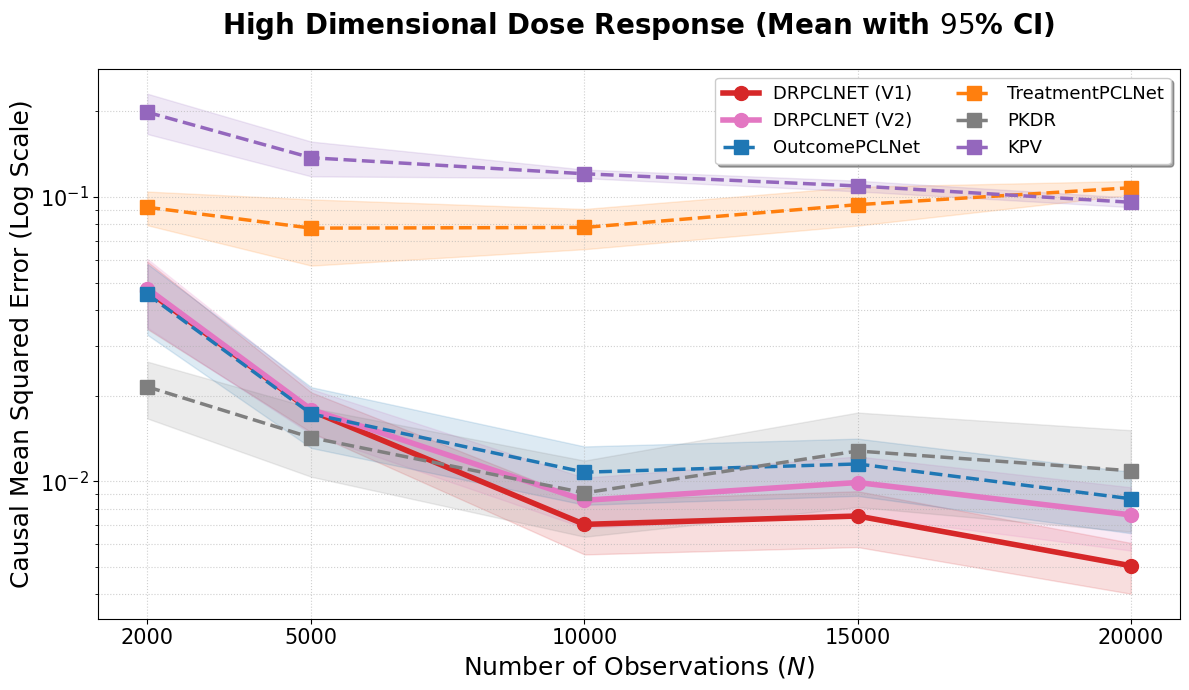

In [4]:
plot_title = f"High Dimensional Dose Response (Mean with $95$% CI)"
high_dim_plot = plot_pcl_convergence_ci(df_results, title = plot_title)
plt.savefig('Figures/DRPCLNET_HighDimATE_Comparison.pdf', format='pdf', bbox_inches = 'tight')
high_dim_plot.show()

In [5]:
format_results_for_jupyter_and_latex(df_results, "Synthetic High Dim", precision=6)

--- Jupyter Visual Preview ---


# Synthetic High Dim Results with MSE and LFBGS

In [6]:
df_NME_2000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_2000_2026-04-24_16-26-42.csv")
df_NME_5000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_5000_2026-04-24_16-26-41.csv")
df_NME_10000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_10000_2026-04-24_16-26-41.csv")
df_NME_15000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_15000_2026-04-24_16-26-41.csv")
df_NME_20000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_20000_2026-04-24_16-26-41.csv")

df_PKDR = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/PKDR_SyntheticHighDim_NewVersion_V1_Results_2000_5000_10000_15000_20000_2026-04-12_16-53-50.csv")
df_KPV = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/KPV_Synthetic_High_Dim_Results_2000_5000_10000_15000_20000_2026-04-24_13-11-12.csv")
df_results = pd.concat([df_NME_2000, df_NME_5000, df_NME_10000, df_NME_15000, df_NME_20000, df_PKDR, df_KPV], axis = 0)

df_NME_20000.tail()

,Algorithm,Data_Size,Seed,Causal_MSE,out_experiment_name,out_disable_first_stage,out_lr_first_stage_base,out_lr_second_stage_ax,out_lr_second_stage_w,out_second_stage_head_lr,...,treat_negative_penalty,third_lr,third_weight_decay,third_n_epochs,third_gap_penalty_weight,third_log_per_epoch,third_input_dim,third_output_dim,third_hidden_dims,third_dropout_rate
115,DRPCLNET_Version2,20000,2800,0.011613,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
116,OutcomeBridgePCLNET,20000,2900,0.026375,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
117,TreatmentBridgePCLNET,20000,2900,0.151675,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
118,DRPCLNET_Version1,20000,2900,0.023700,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
119,DRPCLNET_Version2,20000,2900,0.029798,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1


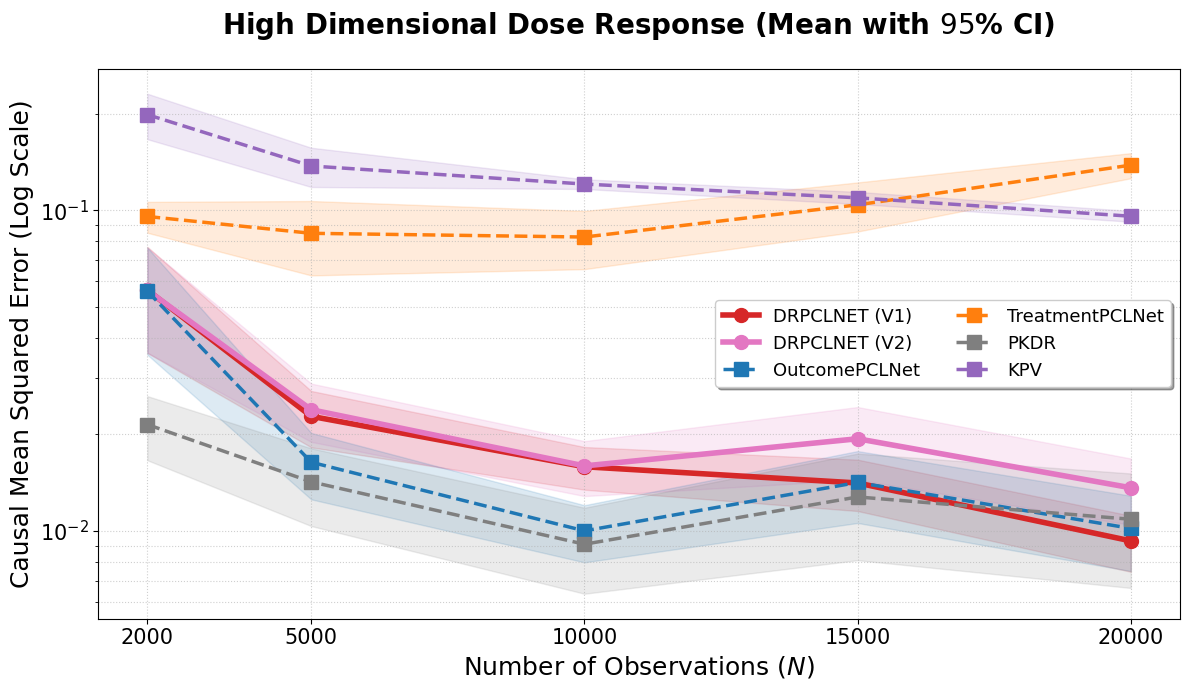

In [7]:
plot_title = f"High Dimensional Dose Response (Mean with $95$% CI)"
high_dim_plot = plot_pcl_convergence_ci(df_results, title = plot_title)
# plt.savefig('Figures/DRPCLNET_HighDimATE_Comparison.pdf', format='pdf', bbox_inches = 'tight')
high_dim_plot.show()

# Synthetic High Dim Results with MSE Closed Form

In [8]:
df_NME_2000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_ClosedForm_2000_2026-04-24_16-27-47.csv")
df_NME_5000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_ClosedForm_5000_2026-04-24_16-27-51.csv")
df_NME_10000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_ClosedForm_10000_2026-04-24_16-27-50.csv")
df_NME_15000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_ClosedForm_15000_2026-04-24_16-27-58.csv")
df_NME_20000 = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/DRPCLNET_SyntheticHighDim_NewVersion_MSE_ClosedForm_20000_2026-04-24_16-27-58.csv")

df_PKDR = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/PKDR_SyntheticHighDim_NewVersion_V1_Results_2000_5000_10000_15000_20000_2026-04-12_16-53-50.csv")
df_KPV = pd.read_csv(r"../Results/Synthetic_High_Dim_Experiment_NewVersion/KPV_Synthetic_High_Dim_Results_2000_5000_10000_15000_20000_2026-04-24_13-11-12.csv")
df_results = pd.concat([df_NME_2000, df_NME_5000, df_NME_10000, df_NME_15000, df_NME_20000, df_PKDR, df_KPV], axis = 0)

df_NME_20000.tail()

,Algorithm,Data_Size,Seed,Causal_MSE,out_experiment_name,out_disable_first_stage,out_lr_first_stage_base,out_lr_second_stage_ax,out_lr_second_stage_w,out_second_stage_head_lr,...,treat_negative_penalty,third_lr,third_weight_decay,third_n_epochs,third_gap_penalty_weight,third_log_per_epoch,third_input_dim,third_output_dim,third_hidden_dims,third_dropout_rate
11,DRPCLNET_Version2,20000,200,0.005681,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
12,OutcomeBridgePCLNET,20000,300,0.005024,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
13,TreatmentBridgePCLNET,20000,300,0.134531,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
14,DRPCLNET_Version1,20000,300,0.004053,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1
15,DRPCLNET_Version2,20000,300,0.004698,outcome_bridge_high_dim_v1,False,0.00005,0.00005,0.00005,0.01,...,0.0,0.0001,0.000001,100.0,0.0,20.0,1.0,1.0,"[128, 128]",0.1


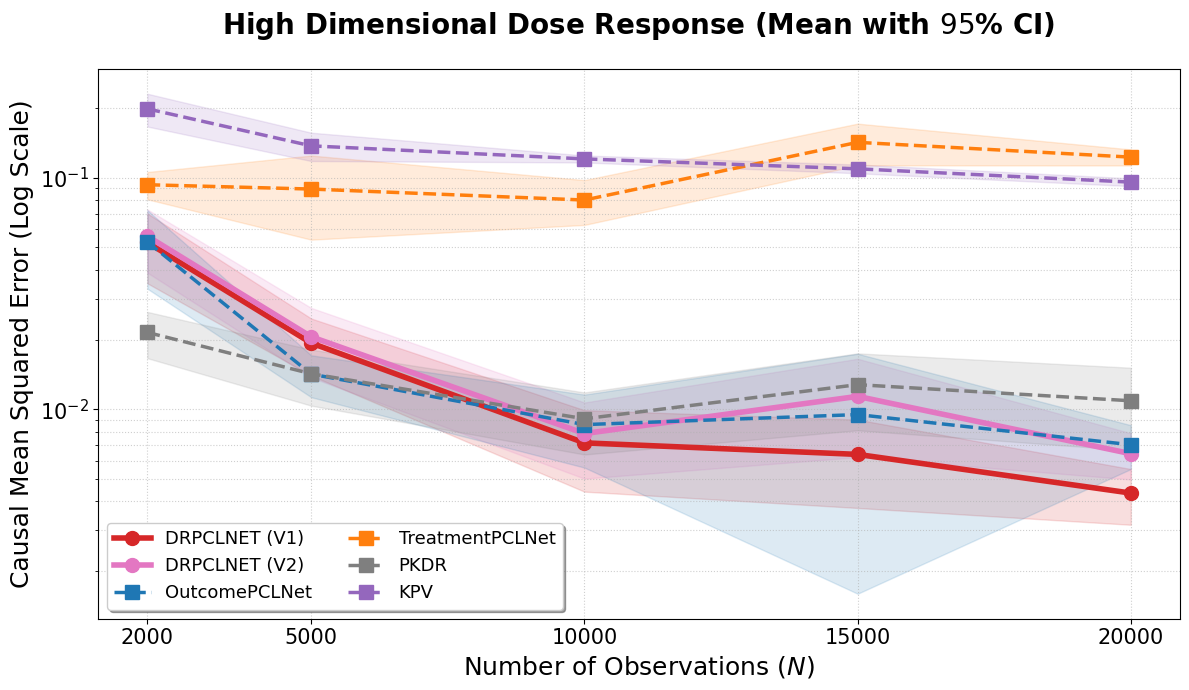

In [9]:
plot_title = f"High Dimensional Dose Response (Mean with $95$% CI)"
high_dim_plot = plot_pcl_convergence_ci(df_results, title = plot_title)
# plt.savefig('Figures/DRPCLNET_HighDimATE_Comparison.pdf', format='pdf', bbox_inches = 'tight')
high_dim_plot.show()